# Case NPS Preditivo
**Objetivo:** Transformar dados operacionais em insights estratégicos para prever e melhorar a satisfação do cliente (NPS).

## 1. Entendimento do Negócio (Business Understanding)
A empresa enfrenta alta variabilidade no NPS. Atualmente, a medição é reativa: o score é coletado apenas após a jornada de compra, o que impede ações preventivas.

**Problema de negócio:** identificar quais fatores operacionais impactam a satisfação do cliente e antecipar clientes propensos a se tornar detratores.

### Inicio do código Python para analisar os dados

In [150]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Configurações de visualização
plt.style.use('default')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14

In [151]:
# Carregamento dos dados
df = pd.read_csv('../data/desafio_nps_fase_1.csv')

In [152]:
# Visão geral da estrutura
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

In [153]:
# Primeiras linhas para reconhecimento visual
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [154]:
# Estatísticas descritivas básicas das variáveis numéricas
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


### Analisando valores ausentes e duplicados

In [155]:
# Verificando valores ausentes
df.isna().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [156]:
# Registros duplicados
df.duplicated().sum()

np.int64(0)

In [157]:
# Remoção de duplicados (se fizer sentido)
df = df.drop_duplicates().reset_index(drop=True)

In [158]:

# Limpeza inicial: Removendo IDs (sem valor preditivo)
df_clean = df.drop(columns=['customer_id', 'order_id'])

# Criações de variáveis: categorização de NPS e alvo de detratores
df_clean['nps_category'] = pd.cut(
    df_clean['nps_score'],
    bins=[-0.1, 6, 8, 10],
    labels=['Detrator', 'Passivo', 'Promotor'],
)
df_clean['is_detractor'] = (df_clean['nps_score'] <= 6).astype(int)

print('Shape do dataset:', df_clean.shape)
df_clean.head()

Shape do dataset: (2500, 19)


,customer_age,customer_region,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_category,is_detractor
0,63,Nordeste,14,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Passivo,0
1,20,Sul,1,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detrator,1
2,46,Nordeste,111,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detrator,1
3,52,Centro-Oeste,117,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detrator,1
4,56,Norte,50,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Passivo,0


## 2. Definição da Target (Target Definition)
**Variável de satisfação:** `nps_score` representa a nota de satisfação do cliente medida de 0 a 10 após a compra.

**Alvo de negócio:** prever clientes detratores antes da aplicação da pesquisa, usando os dados operacionais disponíveis.

**Por que essa variável foi escolhida?**
- É o indicador direto de satisfação usado pelo desafio.
- Já está coletada no momento final da jornada e permite rotular exemplos históricos.

**Momento de coleta:** após o encerramento da experiência de compra.

**Riscos de uso inadequado:**
- Usar `nps_score` como variável de entrada para predição sem garantir que ela seja posterior às decisões operacionais.
- Confundir correlação com causalidade ao propor ações apenas com base em variáveis correlacionadas.

In [159]:
# Verificando possíveis faixas inconsistentes do NPS

df_clean[['nps_score','csat_internal_score']].agg(["min", "max"])

,nps_score,csat_internal_score
min,0.0,0.0
max,10.0,10.0


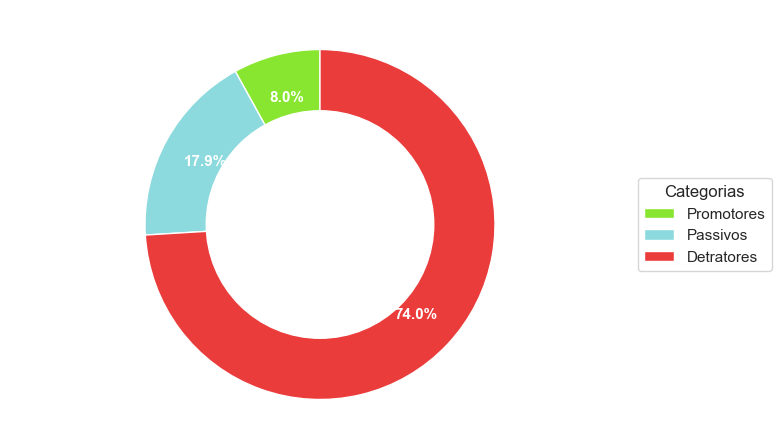

In [ ]:
# Gráfico de composição do NPS
# Calcular proporções (valores entre 0 e 1)
nps_proportions = df_clean['nps_category'].value_counts(normalize=True)

labels = ['Promotores', 'Passivos', 'Detratores']
sizes = [
    nps_proportions.get('Promotor', 0),
    nps_proportions.get('Passivo', 0),
    nps_proportions.get('Detrator', 0)
]
cores = ["#88E631", "#8CDADD", "#EB3C3C"]

# Contagens absolutas para referência
nps_counts = df_clean['nps_category'].value_counts()
counts = [
    nps_counts.get('Promotor', 0),
    nps_counts.get('Passivo', 0),
    nps_counts.get('Detrator', 0)
]

fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=cores,
    textprops=dict(color="white", fontsize=11, fontweight='bold'),
    pctdistance=0.75
)

# Transformando em donut
centro_circulo = plt.Circle((0,0), 0.65, fc="#FFFFFF")
fig.gca().add_artist(centro_circulo)

ax.axis('equal')
plt.title('Composição do NPS', color='white', fontsize=14, fontweight='bold')
plt.legend(wedges, labels, title="Categorias", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()


## 3. Análise Exploratória de Dados (EDA)
Vamos investigar quais variáveis têm maior correlação com a nota final e caracterizar o volume de detratores.

### Graficos para analise Exploratória de Dados

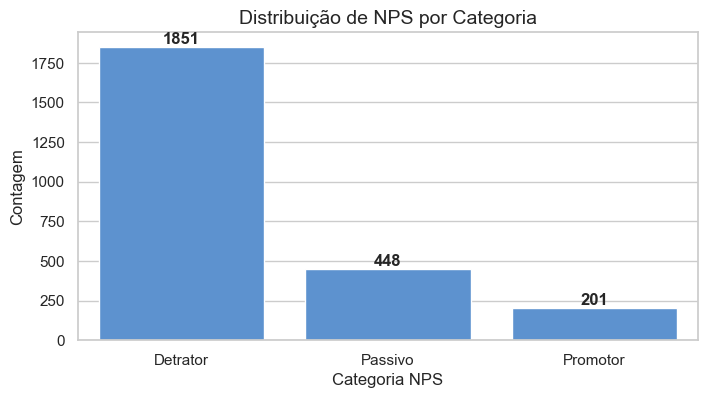

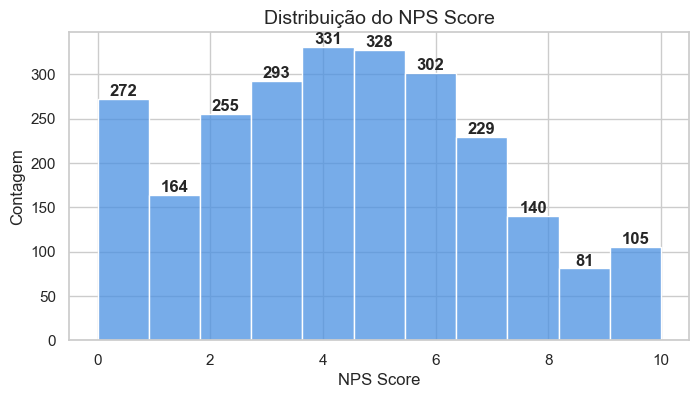

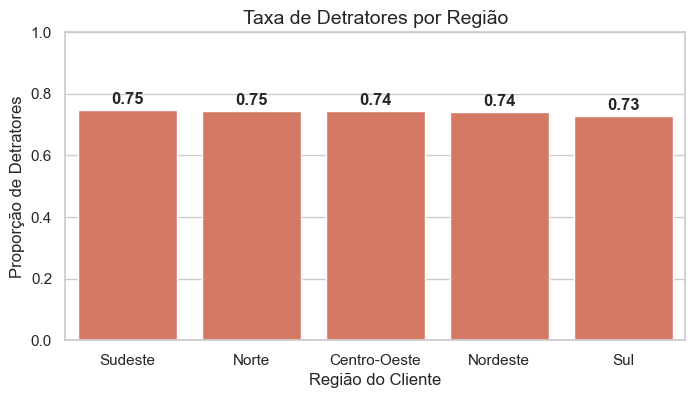

In [161]:
# Distribuição das categorias de NPS
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_clean, x='nps_category', color='#4A90E2')
plt.title('Distribuição de NPS por Categoria')
plt.xlabel('Categoria NPS')
plt.ylabel('Contagem')

# Adicionar valores em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontweight='bold')

plt.show()

# Distribuição das notas de NPS
plt.figure(figsize=(8, 4))
ax = sns.histplot(df_clean['nps_score'], bins=11, kde=False, color='#4A90E2')
plt.title('Distribuição do NPS Score')
plt.xlabel('NPS Score')
plt.ylabel('Contagem')

# Adicionar valores em cima das barras
for p in ax.patches:
    if p.get_height() > 0:  # Só mostra valores para barras com altura > 0
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontweight='bold')

plt.show()

# Taxa de detratores por região
region_detractor_rate = df_clean.groupby('customer_region')['is_detractor'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=region_detractor_rate.index, y=region_detractor_rate.values, color='#E76F51')
plt.title('Taxa de Detratores por Região')
plt.xlabel('Região do Cliente')
plt.ylabel('Proporção de Detratores')
plt.ylim(0, 1)

# Adicionar valores em cima das barras
for i, v in enumerate(region_detractor_rate.values):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.show()

### Analise de motivos dos NPS baixos

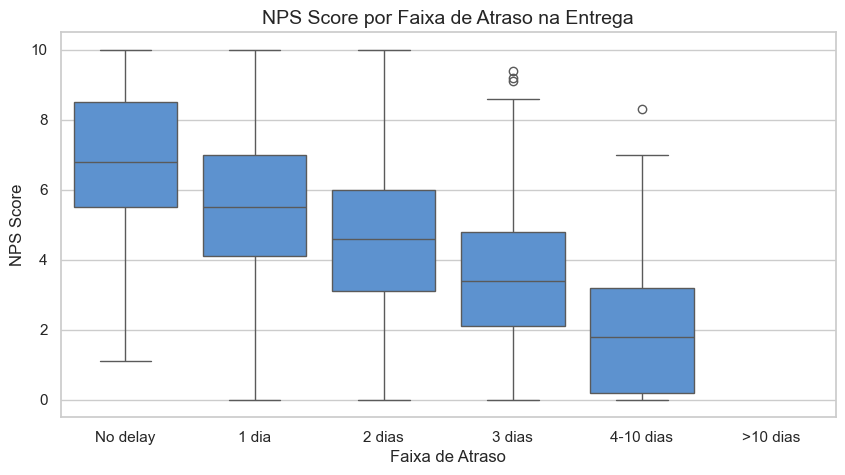

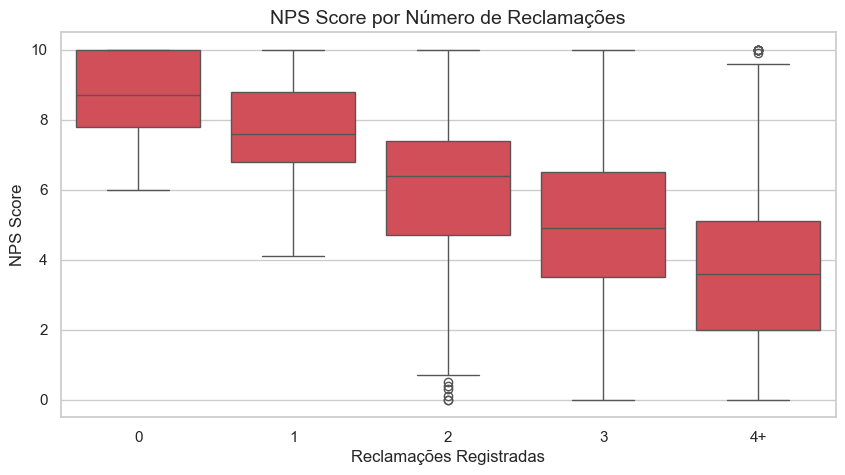

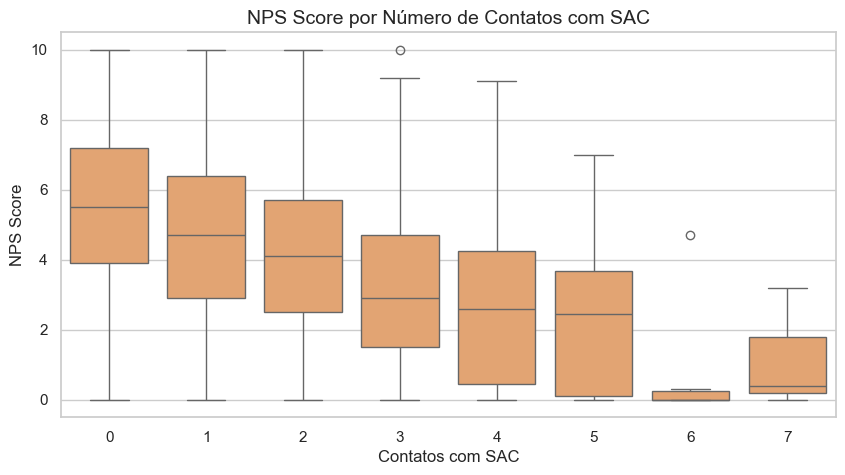

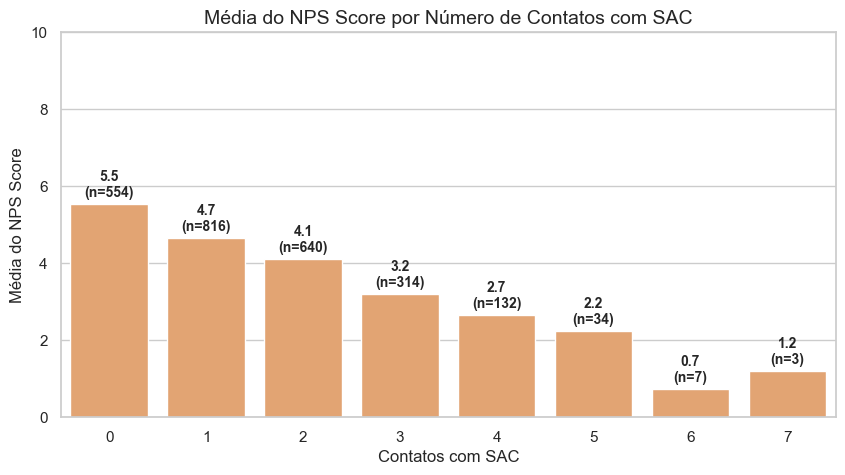

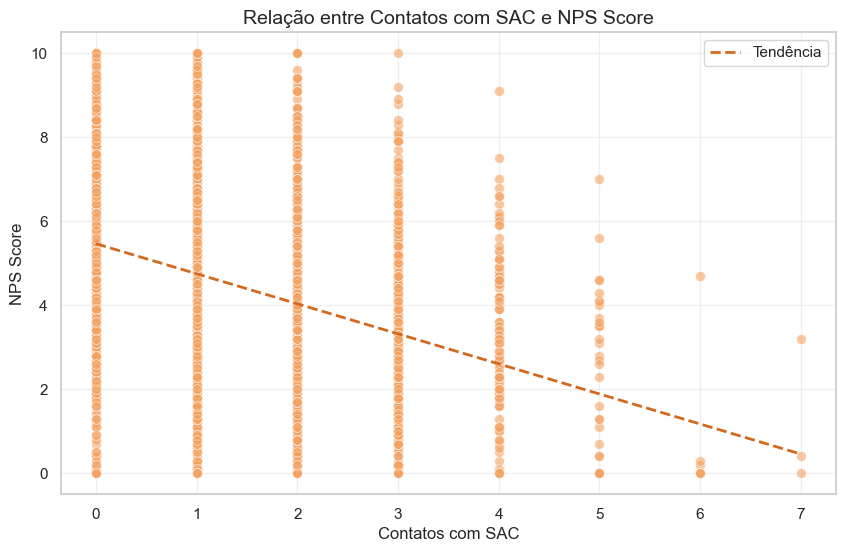

In [162]:
# Gráficos para os principais motivos do NPS baixo
# Atrasos na entrega
delay_labels = ['No delay', '1 dia', '2 dias', '3 dias', '4-10 dias', '>10 dias']
delay_bins = [-1, 0, 1, 2, 3, 10, max(10, df_clean['delivery_delay_days'].max()) + 1]
df_clean['delay_group'] = pd.cut(df_clean['delivery_delay_days'], bins=delay_bins, labels=delay_labels)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='delay_group', y='nps_score', color='#4A90E2')
plt.title('NPS Score por Faixa de Atraso na Entrega')
plt.xlabel('Faixa de Atraso')
plt.ylabel('NPS Score')
plt.show()

# Reclamações e contatos com SAC
complaints_labels = ['0', '1', '2', '3', '4+']
complaints_bins = [-1, 0, 1, 2, 3, df_clean['complaints_count'].max() + 1]
df_clean['complaints_group'] = pd.cut(df_clean['complaints_count'], bins=complaints_bins, labels=complaints_labels)

# Exibimos a relação entre número de reclamações e NPS
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='complaints_group', y='nps_score', color='#E63946')
plt.title('NPS Score por Número de Reclamações')
plt.xlabel('Reclamações Registradas')
plt.ylabel('NPS Score')
plt.show()

# Relação entre número de contatos com SAC e NPS
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='customer_service_contacts', y='nps_score', color='#F4A261')
plt.title('NPS Score por Número de Contatos com SAC')
plt.xlabel('Contatos com SAC')
plt.ylabel('NPS Score')
plt.show()

# Gráfico alternativo: Média do NPS por número de contatos com SAC
contacts_nps_mean = df_clean.groupby('customer_service_contacts')['nps_score'].mean().reset_index()
contacts_nps_count = df_clean.groupby('customer_service_contacts')['nps_score'].count().reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=contacts_nps_mean, x='customer_service_contacts', y='nps_score', color='#F4A261')
plt.title('Média do NPS Score por Número de Contatos com SAC')
plt.xlabel('Contatos com SAC')
plt.ylabel('Média do NPS Score')
plt.ylim(0, 10)

# Adicionar valores em cima das barras
for i, (mean_val, count_val) in enumerate(zip(contacts_nps_mean['nps_score'], contacts_nps_count['nps_score'])):
    ax.text(i, mean_val + 0.1, f'{mean_val:.1f}\n(n={int(count_val)})', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.show()

# Gráfico alternativo: Scatter plot com tendência
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=df_clean, x='customer_service_contacts', y='nps_score', 
                     alpha=0.6, color='#F4A261', s=50)
plt.title('Relação entre Contatos com SAC e NPS Score')
plt.xlabel('Contatos com SAC')
plt.ylabel('NPS Score')

# Adicionar linha de tendência
z = np.polyfit(df_clean['customer_service_contacts'], df_clean['nps_score'], 1)
p = np.poly1d(z)
x_trend = np.linspace(df_clean['customer_service_contacts'].min(), df_clean['customer_service_contacts'].max(), 100)
plt.plot(x_trend, p(x_trend), color='#D2691E', linestyle='--', linewidth=2, label='Tendência')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


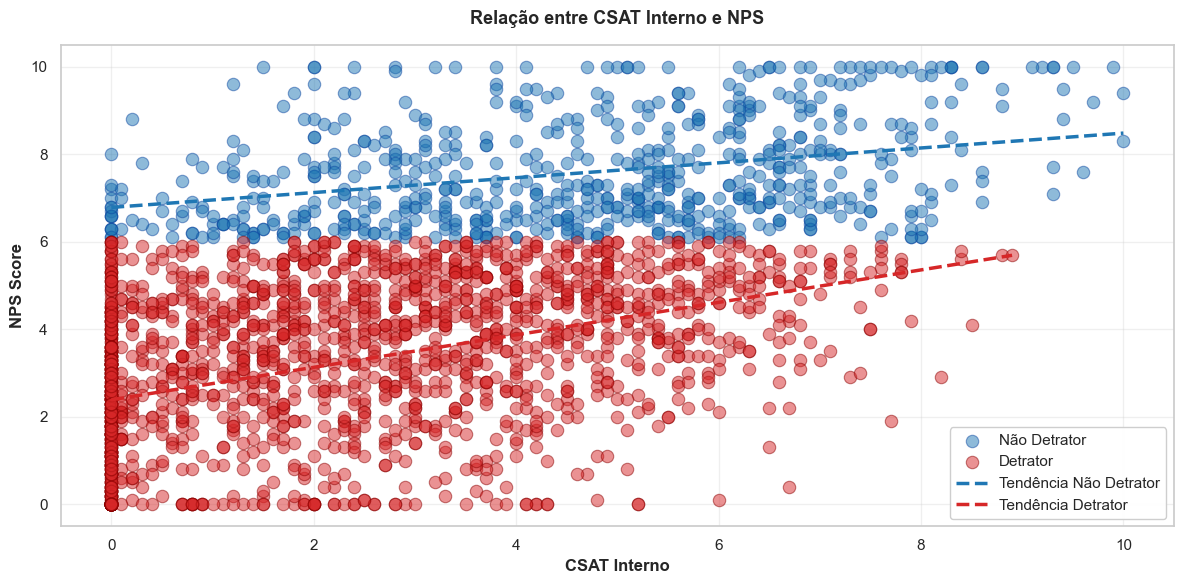

In [163]:
# Relação entre CSAT Interno e NPS
fig, ax = plt.subplots(figsize=(12, 6))

promotores = df_clean[df_clean['is_detractor'] == 0]
detratores = df_clean[df_clean['is_detractor'] == 1]

ax.scatter(promotores['csat_internal_score'], promotores['nps_score'],
           label='Não Detrator', color='#1F77B4', s=80, alpha=0.5, edgecolors='#0D47A1', linewidth=0.8)
ax.scatter(detratores['csat_internal_score'], detratores['nps_score'],
           label='Detrator', color='#D62728', s=80, alpha=0.5, edgecolors='#8B0000', linewidth=0.8)

# Linhas de tendência
z_prom = np.polyfit(promotores['csat_internal_score'], promotores['nps_score'], 1)
p_prom = np.poly1d(z_prom)
x_line = np.linspace(promotores['csat_internal_score'].min(), promotores['csat_internal_score'].max(), 100)
ax.plot(x_line, p_prom(x_line), color='#1F77B4', linestyle='--', linewidth=2.5, label='Tendência Não Detrator')

z_det = np.polyfit(detratores['csat_internal_score'], detratores['nps_score'], 1)
p_det = np.poly1d(z_det)
x_line = np.linspace(detratores['csat_internal_score'].min(), detratores['csat_internal_score'].max(), 100)
ax.plot(x_line, p_det(x_line), color='#D62728', linestyle='--', linewidth=2.5, label='Tendência Detrator')

ax.set_xlabel('CSAT Interno', fontsize=12, fontweight='bold')
ax.set_ylabel('NPS Score', fontsize=12, fontweight='bold')
ax.set_title('Relação entre CSAT Interno e NPS', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best', framealpha=0.95)
plt.tight_layout()
plt.show()


## 4. Por que o NPS está baixo?
Os gráficos acima mostram que os principais motivos do NPS baixo são:
- atrasos na entrega, que reduzem substancialmente a nota média;
- aumento no número de reclamações e de contatos com o SAC;
- relações mais fracas entre CSAT interno e NPS quando o cliente é detrator.

Esses insights serão úteis para destacar visualmente na apresentação as causas do NPS baixo.

## 5. Análise Estatística (Rigor Científico)
Validando se as diferenças observadas são estatisticamente significativas entre entregas no prazo e com atraso.

In [164]:
# Teste de Hipótese: Grupos com Atraso vs. No Prazo
grupo_atraso = df_clean[df_clean['delivery_delay_days'] > 0]['nps_score']
grupo_prazo = df_clean[df_clean['delivery_delay_days'] == 0]['nps_score']

t_stat, p_val = stats.ttest_ind(grupo_atraso, grupo_prazo, equal_var=False)
print(f"Estatística T: {t_stat:.4f} | P-valor: {p_val:.4e}")
if p_val < 0.05:
    print("Resultado: Existe uma diferença estatisticamente significativa entre os grupos.")
else:
    print("Resultado: Não há evidência de diferença significativa.")

Estatística T: -21.2419 | P-valor: 1.4100e-66
Resultado: Existe uma diferença estatisticamente significativa entre os grupos.


## 6. Storytelling e Conclusões Executivas
**Principais Insights:**
1. **Atraso na entrega** é um fator central na redução de NPS e na probabilidade de um cliente ser detrator.
2. **Número de contatos com SAC** também é um sinal importante de maior insatisfação.
3. **Predição de detratores** antes do envio da pesquisa é plausível com os dados operacionais disponíveis.

**Recomendações:**
- Monitorar e priorizar pedidos com atraso maior que 2 dias.
- Investir em resolução no primeiro contato e atendimento proativo.
- Construir um dashboard de risco de detrator para ações imediatas do time de customer success.